In [2]:
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout , Conv2D , MaxPooling2D , Flatten , BatchNormalization

In [4]:
train=keras.utils.image_dataset_from_directory(
    r"C:\Users\user\OneDrive\Desktop\python\Deep learning\cat dog\cat dog\train",
    labels="inferred",
    label_mode="int" ,
    batch_size=32,
    image_size=(256,256)
)


Found 557 files belonging to 2 classes.


In [5]:
test=keras.utils.image_dataset_from_directory(
    r"C:\Users\user\OneDrive\Desktop\python\Deep learning\cat dog\cat dog\test",
    labels="inferred",
    label_mode="int" ,
    batch_size=32,
    image_size=(256,256)
)


Found 140 files belonging to 2 classes.


In [6]:
list(train)[0]

(<tf.Tensor: shape=(32, 256, 256, 3), dtype=float32, numpy=
 array([[[[178.08594  , 196.08594  , 200.08594  ],
          [179.51562  , 197.51562  , 201.51562  ],
          [181.85938  , 199.85938  , 203.85938  ],
          ...,
          [138.14844  , 119.71875  , 101.86719  ],
          [133.03125  , 112.80469  ,  93.546875 ],
          [128.34375  , 107.34375  ,  86.515625 ]],
 
         [[175.17969  , 193.17969  , 197.17969  ],
          [176.4845   , 194.4845   , 198.4845   ],
          [178.67688  , 196.67688  , 200.67688  ],
          ...,
          [137.17969  , 118.75     , 100.89844  ],
          [132.0625   , 111.83594  ,  92.578125 ],
          [127.81775  , 106.81775  ,  85.989624 ]],
 
         [[171.38281  , 188.96094  , 192.82031  ],
          [172.59094  , 190.16907  , 194.02844  ],
          [174.66614  , 192.24426  , 196.10364  ],
          ...,
          [135.94739  , 117.095825 ,  99.38489  ],
          [130.78625  , 110.24219  ,  91.125    ],
          [126.97656  

# Batch Normalization 

In [7]:
def process(image,label):
    image = tf.cast(image/255,tf.float32)
    return image,label

In [8]:
train = train.map(process)
test = test.map(process)

In [9]:
list(test)

[(<tf.Tensor: shape=(32, 256, 256, 3), dtype=float32, numpy=
  array([[[[0.9626225 , 0.7798101 , 0.48817402],
           [0.9564032 , 0.7291054 , 0.4425858 ],
           [0.99191177, 0.76121324, 0.47493872],
           ...,
           [0.9934436 , 0.8397365 , 0.5965993 ],
           [0.94402575, 0.7840074 , 0.5408701 ],
           [0.978125  , 0.8272978 , 0.58416057]],
  
          [[0.95643383, 0.8051777 , 0.49246323],
           [0.9511029 , 0.7593137 , 0.45646447],
           [0.9287071 , 0.7090993 , 0.40713847],
           ...,
           [0.97552085, 0.81498164, 0.57208943],
           [0.9789522 , 0.82117033, 0.5782782 ],
           [0.96721816, 0.810815  , 0.5679228 ]],
  
          [[0.9548713 , 0.71139705, 0.42098653],
           [0.9968137 , 0.76887256, 0.46813726],
           [0.91979164, 0.69708943, 0.38507965],
           ...,
           [0.9740502 , 0.7651961 , 0.49264705],
           [0.9632966 , 0.7544424 , 0.4818934 ],
           [0.9318934 , 0.72542894, 0.4499387 ]],


# Model [CNN]

In [10]:
model=Sequential()

In [11]:
model.add(Conv2D(32, kernel_size=(3,3) , padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3) , padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3) , padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 254, 254, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 125, 125, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 60, 60, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 115200)              │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 94,144 (367.75 KB)

 Trainable params: 93,696 (366.00 KB)

 Non-trainable params: 448 (1.75 KB)

# ANN 

In [13]:
model.add(Dense(128 , activation = 'relu'))
model.add(Dropout(0.3))

model.add(Dense(64 , activation = 'relu'))
model.add(Dropout(0.3))

model.add(Dense(32 , activation = 'relu'))
model.add(Dropout(0.3))

model.add(Dense(1 , activation = 'sigmoid'))

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 254, 254, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 125, 125, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 60, 60, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      14,745,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,850,241 (56.65 MB)

 Trainable params: 14,849,793 (56.65 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
model.compile(loss =  'binary_crossentropy' , optimizer='adam' , metrics=['accuracy'])

In [16]:
history=model.fit(train,epochs=2)

Epoch 1/2
18/18 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.5135 - loss: 6.2493
Epoch 2/2
18/18 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - accuracy: 0.5476 - loss: 6.3680


In [17]:
import cv2
import matplotlib.pyplot as plt 

In [18]:
test_img=cv2.imread(r"C:\Users\user\OneDrive\Desktop\python\Deep learning\cat dog\cat dog\test\cats\cat_106.jpg")
    

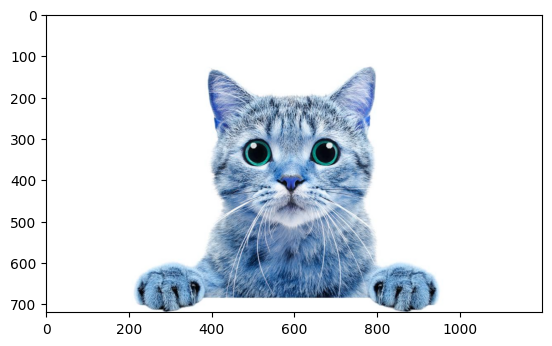

In [20]:
plt.imshow(test_img)

In [21]:
test_img.shape

(720, 1200, 3)

In [22]:
inputs = cv2.resize(test_img,(256,256))
inputs=inputs.reshape(1,256,256,3)

In [23]:
inputs.shape

(1, 256, 256, 3)

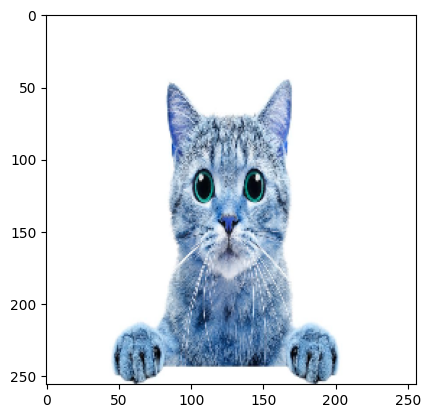

In [24]:
plt.imshow(inputs[0])

In [25]:
model.predict(inputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step


array([[0.]], dtype=float32)

In [26]:
model.evaluate(test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 401ms/step - accuracy: 0.4429 - loss: 0.9685


[0.9685162305831909, 0.44285714626312256]

In [27]:
model.save('model.h5')